In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

print(mssfp.__version__)

0.0.5


In [2]:
mode = deepssfp.DataMode.SuperFOV.value
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
ds_path = os.path.join(model_dir, f"{model_name}_dataset.npy")
print(path, ds_path)


D:/DeepSSFP/block_phantom_superfov D:/DeepSSFP/block_phantom_dataset.npy


Saved dataset found. Loading from file: D:/DeepSSFP/block_phantom_dataset.npy


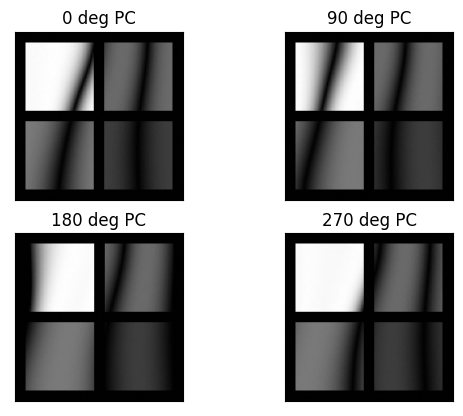

(160, 128, 128, 2) (160, 128, 128, 2)
5.74093778970536e-05 12.170648866974298 -2.2384944039016835e-06 10.137715712146786
Selected indices: [13]
Figure size: (4, 2)


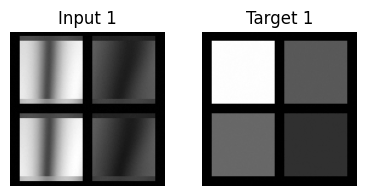

In [4]:
if(os.path.isfile(ds_path)):
    print(f'Saved dataset found. Loading from file: {ds_path}')
    dataset = np.load(ds_path, allow_pickle=True)[0]
else:
    slices = 200
    dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4],
                                          npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                          useRotate=True, useDeform=True)
    np.save(ds_path, [dataset])

data = dataset['M']
data.shape
mssfp.plot_dataset(data, slice=0)
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)
print(ds.inputScaler.mean, ds.inputScaler.std, ds.outputScaler.mean, ds.outputScaler.std)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=1,
    kspace = True
)

In [ ]:
# Basic training
model, history, ds, predictions = deepssfp.train(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir,
    custom_dataset=ds,
    epochs=400,
    use_early_stopping=False,
    patience=200,2
    continue_training=True
)

2025-03-21 17:04:03,796 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_superfov
2025-03-21 17:04:03,797 - DeepSSFP - INFO - Training DataSet: (160, 128, 128, 2) | (160, 128, 128, 2)
2025-03-21 17:04:03,797 - DeepSSFP - INFO - Test DataSet: (40, 128, 128, 2) | (40, 128, 128, 2)
2025-03-21 17:04:04,409 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x2→2


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 2) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-21 17:04:12,956 - tensorflow - WARNING - Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0236s vs `on_train_batch_end` time: 0.1982s). Check your callbacks.


20/20 - 9s - loss: 0.8907 - mean_absolute_error: 0.3360 - val_loss: 0.7373 - val_mean_absolute_error: 0.2399

Epoch 00001: val_loss improved from inf to 0.73726, saving model to D:/DeepSSFP\block_phantom_superfov.keras
Epoch 2/400
20/20 - 1s - loss: 0.1443 - mean_absolute_error: 0.1436 - val_loss: 0.1839 - val_mean_absolute_error: 0.1687

Epoch 00002: val_loss improved from 0.73726 to 0.18392, saving model to D:/DeepSSFP\block_phantom_superfov.keras
Epoch 3/400
20/20 - 1s - loss: 0.0894 - mean_absolute_error: 0.1003 - val_loss: 0.0965 - val_mean_absolute_error: 0.1088

Epoch 00003: val_loss improved from 0.18392 to 0.09651, saving model to D:/DeepSSFP\block_phantom_superfov.keras
Epoch 4/400
20/20 - 1s - loss: 0.0692 - mean_absolute_error: 0.0851 - val_loss: 0.0763 - val_mean_absolute_error: 0.0938

Epoch 00004: val_loss improved from 0.09651 to 0.07627, saving model to D:/DeepSSFP\block_phantom_superfov.keras
Epoch 5/400
20/20 - 1s - loss: 0.0571 - mean_absolute_error: 0.0771 - val_lo

2025-03-21 17:17:44,802 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_superfov.keras


2/2 [==============================] - 1s 7ms/step - loss: 0.0077 - mean_absolute_error: 0.0216


2025-03-21 17:17:46,294 - DeepSSFP - INFO - Training Complete. Loss: 0.0077, MAE: 0.0216
2025-03-21 17:17:46,295 - DeepSSFP - INFO - Time Elapsed: 820.41 seconds


2025-03-21 17:17:46,317 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_superfov
2025-03-21 17:17:46,847 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_superfov.keras
2025-03-21 17:17:46,848 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_superfov_history.npz
2025-03-21 17:17:47,869 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_superfov_training_history.png


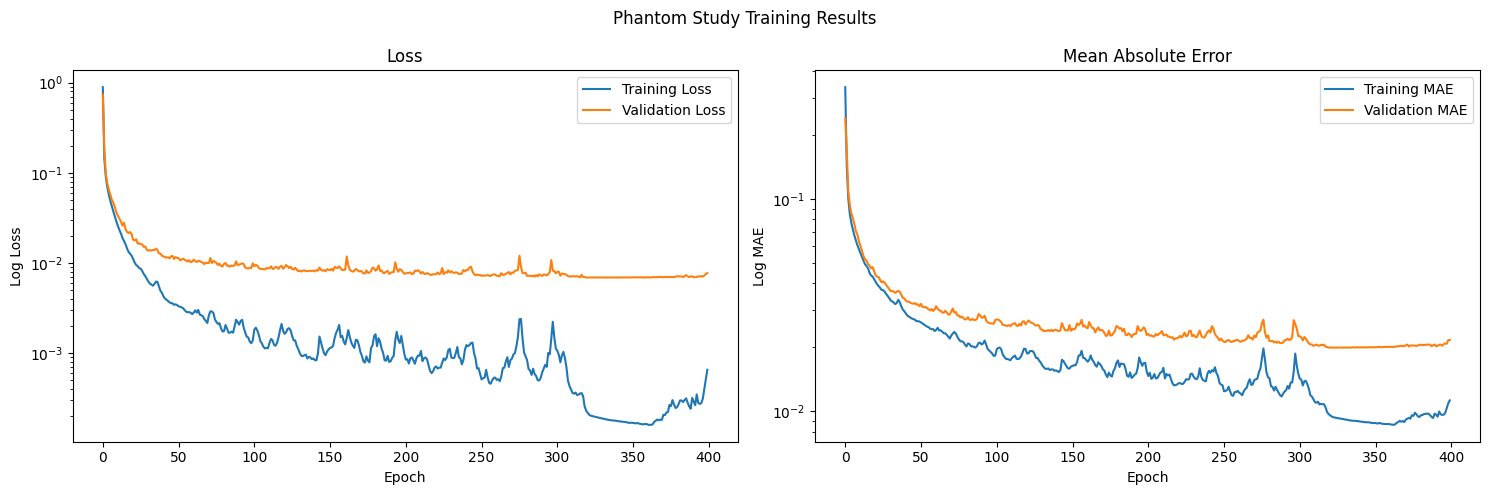

In [6]:
model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir
)

deepssfp.plot_training_history(
    history_dict,
    title="Phantom Study Training Results",
    save_path=f"{path}_training_history.png"
)

2025-03-21 17:17:58,590 - DeepSSFP - INFO - Making predictions on data with shape (40, 128, 128, 2)
2025-03-21 17:17:59,032 - DeepSSFP - INFO - Predictions complete. Output shape: (40, 128, 128, 2)


Selected indices: [9 2]
Figure size: (6, 4)
Image visualization saved to D:/DeepSSFP/block_phantom_superfov_prediction_results2.png


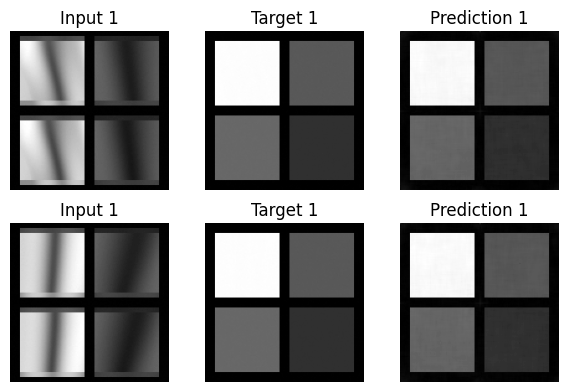

In [ ]:
ds = deepssfp.Dataset(mode, input_data=data)
x_test = ds.inputScaler.inverse_transform(ds.x_test)
y_test = ds.outputScaler.inverse_transform(ds.y_test)
predictions = ds.outputScaler.inverse_transform(deepssfp.predict(model, ds.x_test))

deepssfp.visualize_images(
    input_images=x_test,
    target_images=y_test,
    predicted_images=predictions,
    num_samples=2,
    kspace = True,
    save_path=f"{path}_prediction_results.png"
)

(40, 128, 128) (40, 128, 128)


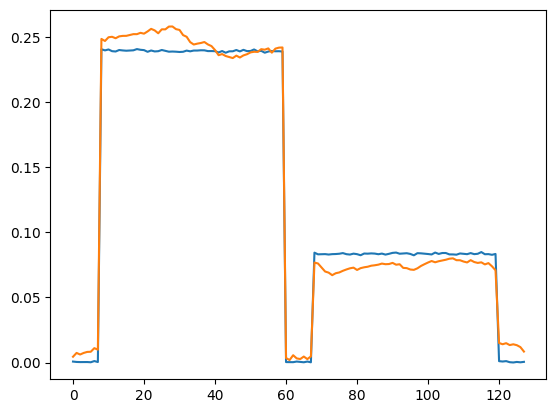

Target shape: (40, 128, 128)
Prediction shape: (40, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4.]
IDs to plot: [1. 2. 3. 4.]
Training history plot saved to D:/DeepSSFP/block_phantom_superfov_metrics2_scatter


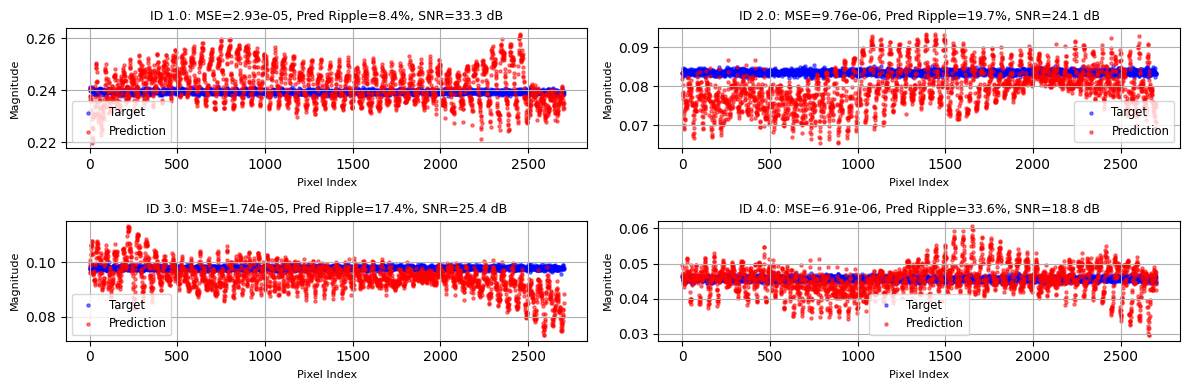

Training history plot saved to D:/DeepSSFP/block_phantom_superfov_metrics2


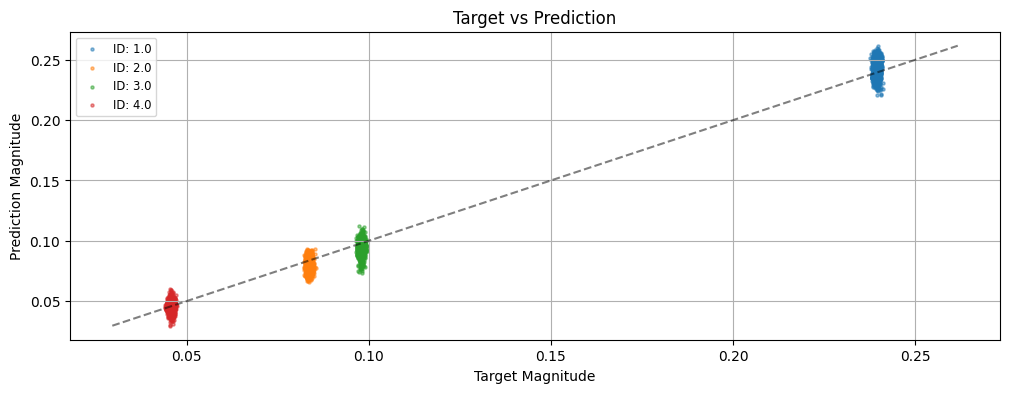


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=2.93e-05, MAE=3.59e-03, Pred Min=0.2273, Pred Max=0.2470, Pred Ripple=8.36%, Pred SNR=33.3 dB, Target Min=0.2374, Target Max=0.2415, Target Ripple=1.70%, Target SNR=50.4 dB, Samples=40, Pixels=2704
ID 2.0: MSE=9.76e-06, MAE=2.13e-03, Pred Min=0.0746, Pred Max=0.0910, Pred Ripple=19.69%, Pred SNR=24.1 dB, Target Min=0.0818, Target Max=0.0854, Target Ripple=4.29%, Target SNR=41.3 dB, Samples=40, Pixels=2704
ID 3.0: MSE=1.74e-05, MAE=2.88e-03, Pred Min=0.0874, Pred Max=0.1040, Pred Ripple=17.36%, Pred SNR=25.4 dB, Target Min=0.0960, Target Max=0.0997, Target Ripple=3.77%, Target SNR=42.7 dB, Samples=40, Pixels=2704
ID 4.0: MSE=6.91e-06, MAE=1.85e-03, Pred Min=0.0366, Pred Max=0.0516, Pred Ripple=33.60%, Pred SNR=18.8 dB, Target Min=0.0439, Target Max=0.0475, Target Ripple=7.89%, Target SNR=36.1 dB, Samples=40, Pixels=2704
{1.0: {'mse': 2.930945257823548e-05, 'mae': 0.0035914570859121907, 'pred_min': 0.22726036235081012, 'pr

In [ ]:
pred = deepssfp.ifft(deepssfp.from_pairs_to_complex(predictions))
target = deepssfp.ifft(deepssfp.from_pairs_to_complex(y_test))
print(target.shape, pred.shape)

plt.plot(np.abs(target[0,20,:]))
plt.plot(np.abs(pred[0,20,:]))
plt.show()

metrics = deepssfp.evaluate_band_reduction(target, pred, dataset['seg'], sort_values=False, fig_size=(6, 2), save_path=f"{path}_metrics2")
print(metrics)